## Multivariate VAR: No-BoE-Intervention Counterfactual

This notebook uses exactly the same four-variable VAR system and the same lag-selection rule as the pre-crisis VAR notebook (7).

The VAR lag order is selected using the **pre-crisis training sample only**, so model specification is not chosen using intervention-period outcomes.

The model is then refitted using all available information through **27 September 2022** and forecasts from **28 September onward** without receiving any post-intervention observations.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

SEED = 42
np.random.seed(SEED)

In [2]:
SERIES_CODES = {
    "XUDLGBD": "gbpusd",
    "IUDSNZC": "yield_5y",
    "IUDMNZC": "yield_10y",
    "IUDLNZC": "yield_20y",
}

SOURCE_FILE = Path("Bank of England Database VAR.csv")

PROCESSED_DIR = Path("data") / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_FILE = (
    PROCESSED_DIR /
    "boe_var_multivariate_2014_2024.csv"
)

if not SOURCE_FILE.exists():
    raise FileNotFoundError(
        f"Could not find: {SOURCE_FILE.resolve()}"
    )

raw = pd.read_csv(SOURCE_FILE)

print(f"Loaded: {SOURCE_FILE}")
print(f"Rows: {len(raw)}")
print(raw.columns.tolist())

raw.head()

Loaded: Bank of England Database VAR.csv
Rows: 2779
['DATE', 'XUDLGBD', 'IUDSNZC', 'IUDMNZC', 'IUDLNZC']


,DATE,XUDLGBD,IUDSNZC,IUDMNZC,IUDLNZC
0,02 Jan 2014,0.6084,1.9782,3.1625,3.7449
1,03 Jan 2014,0.6081,1.9771,3.1579,3.7305
2,06 Jan 2014,0.6093,1.9293,3.1053,3.7073
3,07 Jan 2014,0.6098,1.9185,3.0831,3.6906
4,08 Jan 2014,0.6072,1.9674,3.1140,3.7060


In [3]:
def identify_date_column(columns):
    for c in columns:
        if str(c).strip().lower() in {"date", "dates"}:
            return c
    return columns[0]

date_col = identify_date_column(raw.columns)

rename_map = {date_col: "date"}
for code, short_name in SERIES_CODES.items():
    matching = [c for c in raw.columns if code.lower() in str(c).lower()]
    if matching:
        rename_map[matching[0]] = short_name

data = raw.rename(columns=rename_map).copy()

missing = {"date", *SERIES_CODES.values()} - set(data.columns)
if missing:
    raise ValueError(
        f"Could not identify these expected columns: {missing}. "
        f"Columns found were: {list(raw.columns)}"
    )

data = data[["date", "gbpusd", "yield_5y", "yield_10y", "yield_20y"]].copy()
data["date"] = pd.to_datetime(data["date"], dayfirst=True, errors="coerce")

for c in ["gbpusd", "yield_5y", "yield_10y", "yield_20y"]:
    data[c] = pd.to_numeric(data[c], errors="coerce")

data = (
    data.dropna()
        .sort_values("date")
        .drop_duplicates("date")
        .reset_index(drop=True)
)

data["fx_return_pct"] = 100 * np.log(data["gbpusd"] / data["gbpusd"].shift(1))
data["d5y_bps"] = data["yield_5y"].diff() * 100
data["d10y_bps"] = data["yield_10y"].diff() * 100
data["d20y_bps"] = data["yield_20y"].diff() * 100

data.to_csv(PROCESSED_FILE, index=False)

VAR_COLUMNS = ["fx_return_pct", "d5y_bps", "d10y_bps", "d20y_bps"]

print(f"Observations: {len(data)}")
print(f"Date range: {data['date'].min().date()} to {data['date'].max().date()}")
data.head()

Observations: 2779
Date range: 2014-01-02 to 2024-12-31


,date,gbpusd,yield_5y,yield_10y,yield_20y,fx_return_pct,d5y_bps,d10y_bps,d20y_bps
0,2014-01-02,0.6084,1.9782,3.1625,3.7449,NaN,NaN,NaN,NaN
1,2014-01-03,0.6081,1.9771,3.1579,3.7305,-0.049322,-0.11,-0.46,-1.44
2,2014-01-06,0.6093,1.9293,3.1053,3.7073,0.197142,-4.78,-5.26,-2.32
3,2014-01-07,0.6098,1.9185,3.0831,3.6906,0.082028,-1.08,-2.22,-1.67
4,2014-01-08,0.6072,1.9674,3.1140,3.7060,-0.427281,4.89,3.09,1.54


### Recover the pre-crisis VAR lag specification

In [4]:
CRISIS_START = pd.Timestamp("2022-09-23")
INFO_CUTOFF = pd.Timestamp("2022-09-27")
INTERVENTION_DATE = pd.Timestamp("2022-09-28")
COUNTERFACTUAL_END = pd.Timestamp("2022-10-14")
VALIDATION_SIZE = 60

pre_crisis = data.loc[data["date"] < CRISIS_START].copy().reset_index(drop=True)
train_level = pre_crisis.iloc[:-VALIDATION_SIZE].copy().reset_index(drop=True)
train_stationary = train_level.dropna(subset=VAR_COLUMNS).copy().reset_index(drop=True)

MAX_LAGS = 10
lag_selection = VAR(train_stationary[VAR_COLUMNS]).select_order(maxlags=MAX_LAGS)
print(lag_selection.summary())

BEST_LAG = lag_selection.selected_orders["aic"]
if BEST_LAG is None or BEST_LAG < 1:
    BEST_LAG = 1

print("Pre-crisis AIC-selected VAR lag:", BEST_LAG)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        2.772       2.782       15.99       2.776
1        2.697      2.750*       14.83      2.716*
2        2.686       2.782       14.67       2.721
3       2.670*       2.808      14.44*       2.721
4        2.674       2.855       14.50       2.740
5        2.671       2.894       14.45       2.752
6        2.675       2.941       14.52       2.772
7        2.676       2.984       14.52       2.788
8        2.682       3.033       14.62       2.811
9        2.686       3.079       14.68       2.830
10       2.688       3.124       14.70       2.847
--------------------------------------------------
Pre-crisis AIC-selected VAR lag: 3


### Construct the information set through 27 September

In [5]:
information_set = data.loc[data["date"] <= INFO_CUTOFF].copy().reset_index(drop=True)
information_stationary = information_set.dropna(subset=VAR_COLUMNS).copy().reset_index(drop=True)

stationary_sample = information_stationary

counterfactual_window = data.loc[
    data["date"].between(INTERVENTION_DATE, COUNTERFACTUAL_END)
].copy().reset_index(drop=True)

print("Information cutoff:", information_set["date"].max().date())
print("Counterfactual start:", counterfactual_window["date"].min().date())
print("Counterfactual end:", counterfactual_window["date"].max().date())

Information cutoff: 2022-09-27
Counterfactual start: 2022-09-28
Counterfactual end: 2022-10-14


### Stationarity checks

In [6]:
def adf_table(df, columns):
    rows = []
    for c in columns:
        s = df[c].dropna().astype(float)
        stat, pvalue, usedlag, nobs, crit, icbest = adfuller(s, autolag="AIC")
        rows.append({
            "series": c,
            "ADF statistic": stat,
            "p-value": pvalue,
            "used lags": usedlag,
            "nobs": nobs,
            "1% critical": crit["1%"],
            "5% critical": crit["5%"],
            "10% critical": crit["10%"],
        })
    return pd.DataFrame(rows)

adf_results = adf_table(stationary_sample, VAR_COLUMNS)
adf_results

,series,ADF statistic,p-value,used lags,nobs,1% critical,5% critical,10% critical
0,fx_return_pct,-19.116555,0.0,5,2201,-3.433325,-2.862854,-2.567470
1,d5y_bps,-19.704843,0.0,3,2203,-3.433322,-2.862853,-2.567469
2,d10y_bps,-45.981019,0.0,0,2206,-3.433318,-2.862851,-2.567468
3,d20y_bps,-43.662176,0.0,0,2206,-3.433318,-2.862851,-2.567468


### Fit the pre-intervention VAR

In [7]:
var_fit = VAR(information_stationary[VAR_COLUMNS]).fit(BEST_LAG, trend="c")
print(var_fit.summary())
print("\nStable VAR:", var_fit.is_stable())

whiteness_lags = max(10, BEST_LAG + 5)
print("\nResidual whiteness test")
print(var_fit.test_whiteness(nlags=whiteness_lags))

print("\nResidual normality test")
print(var_fit.test_normality())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 30, Aug, 2026
Time:                     10:34:01
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    3.36285
Nobs:                     2204.00    HQIC:                   3.27753
Log likelihood:          -16015.1    FPE:                    25.2395
AIC:                      3.22841    Det(Omega_mle):         24.6527
--------------------------------------------------------------------
Results for equation fx_return_pct
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.016375         0.012755            1.284           0.199
L1.fx_return_pct         0.051737         0.021696            2.385           0.017
L1.d5y_bps              -0.004519       

The VAR(3) is refitted using the full **pre-intervention information set through 27 September 2022** before generating the fixed-origin **no-BoE-intervention counterfactual**. The model remains stable, and the gilt equations continue to show substantial interactions across the 5-, 10- and 20-year yield curve, while sterling effects are generally weaker.

However, the residual whiteness test rejects the null of no residual autocorrelation ($p=0.001$), and residual normality is also rejected. Therefore, the VAR results, including the Granger tests, impulse responses, FEVD and counterfactual forecasts, should be interpreted with this remaining model limitation in mind.

### Granger-predictability tests using information through 27 September

In [8]:
causality_rows = []

tests = [
    ("d10y_bps", ["fx_return_pct"], "GBP/USD return → 10y yield change"),
    ("fx_return_pct", ["d10y_bps"], "10y yield change → GBP/USD return"),
    ("d10y_bps", ["d5y_bps"], "5y yield change → 10y yield change"),
    ("d10y_bps", ["d20y_bps"], "20y yield change → 10y yield change"),
]

for caused, causing, label in tests:
    test = var_fit.test_causality(
        caused=caused,
        causing=causing,
        kind="f"
    )
    causality_rows.append({
        "direction": label,
        "test statistic": float(test.test_statistic),
        "p-value": float(test.pvalue),
        "df": str(test.df),
    })

granger_table = pd.DataFrame(causality_rows)
granger_table

,direction,test statistic,p-value,df
0,GBP/USD return → 10y yield change,1.262049,2.855720e-01,"(3, np.int64(8764))"
1,10y yield change → GBP/USD return,1.383166,2.458431e-01,"(3, np.int64(8764))"
2,5y yield change → 10y yield change,22.394984,1.935923e-14,"(3, np.int64(8764))"
3,20y yield change → 10y yield change,1.861966,1.336747e-01,"(3, np.int64(8764))"


Within the VAR(3) specification, there is no statistically significant Granger-predictive relationship between sterling returns and 10-year gilt-yield changes in either direction ($p=0.286$ and $p=0.246$).

The 5-year yield change provides significant predictive information for the 10-year yield change ($p<0.001$), while the 20-year yield change does not ($p=0.134$). These inference results should be interpreted cautiously because some residual autocorrelation remains in the fitted VAR.

### Impulse responses

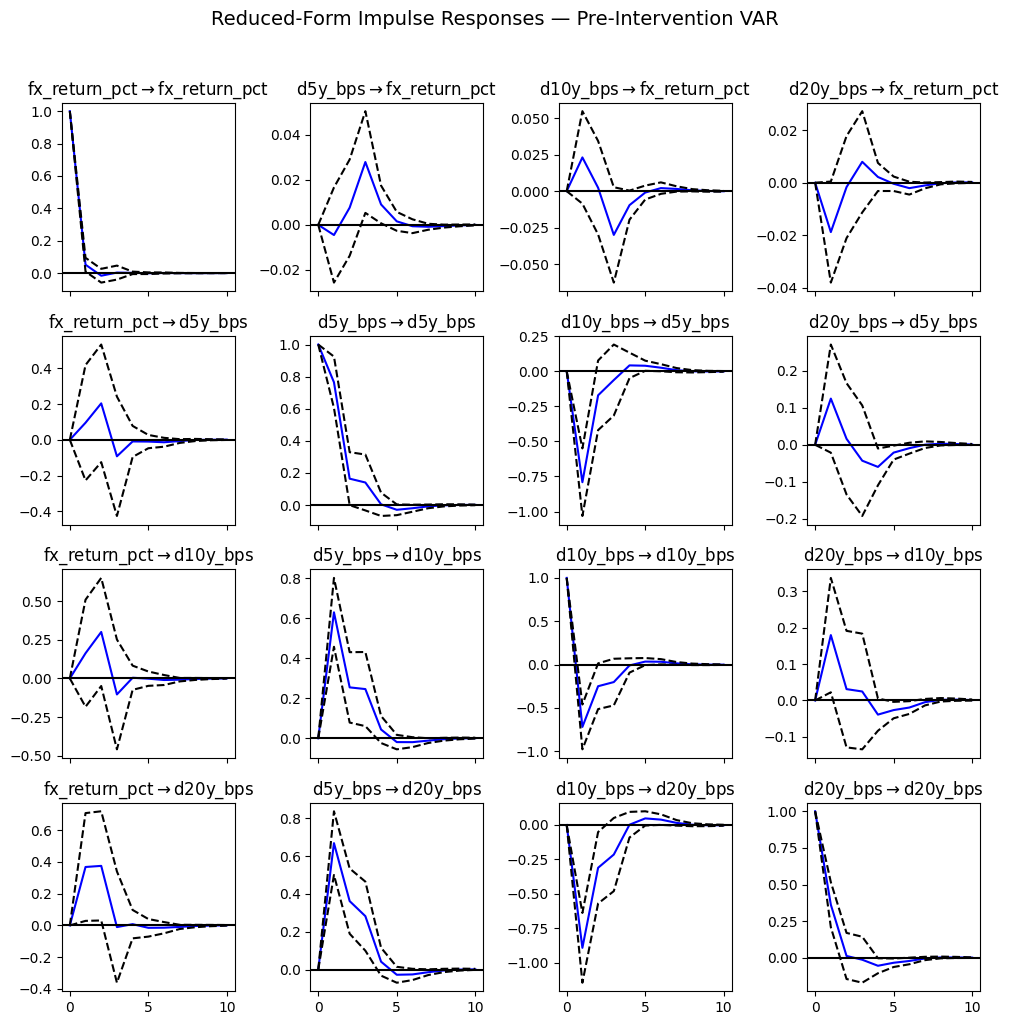

In [9]:
IRF_HORIZON = 10

irf = var_fit.irf(IRF_HORIZON)

fig = irf.plot(orth=False)
fig.suptitle(
    "Reduced-Form Impulse Responses — Pre-Intervention VAR",
    y=1.02,
    fontsize=14
)
plt.tight_layout()
plt.show()

The impulse responses continue to show the strongest short-run interactions **within the gilt yield curve**, especially between the 5-, 10- and 20-year yield changes. Most responses decay back toward zero within a few trading days.

Sterling-return shocks generate some temporary movements in gilt yields, but the confidence bands generally include zero, so the evidence remains weak compared with the gilt-to-gilt responses.

The pre-intervention VAR suggests that the main dynamic transmission during this information set is still within the gilt market rather than between sterling and gilt yields. These reduced-form responses are descriptive and should not be interpreted as causal effects.

### Forecast error variance decomposition

The FEVD uses the variable ordering:

`GBP/USD return → 5y yield change → 10y yield change → 20y yield change`.

Because the FEVD uses an orthogonalised shock decomposition, the numerical contributions depend on the chosen variable ordering and should therefore be interpreted as ordering-specific rather than structural causal effects.

FEVD for fx_return_pct
     fx_return_pct   d5y_bps  d10y_bps  d20y_bps
0         1.000000  0.000000  0.000000  0.000000
1         0.998016  0.000248  0.000057  0.001679
2         0.993981  0.004277  0.000057  0.001684
3         0.990625  0.005289  0.002108  0.001977
4         0.990282  0.005366  0.002353  0.001999
5         0.990265  0.005368  0.002367  0.002000
6         0.990235  0.005375  0.002370  0.002020
7         0.990227  0.005378  0.002370  0.002025
8         0.990226  0.005378  0.002371  0.002025
9         0.990225  0.005378  0.002371  0.002025

FEVD for d5y_bps
     fx_return_pct   d5y_bps  d10y_bps  d20y_bps
0         0.028610  0.971390  0.000000  0.000000
1         0.027410  0.934419  0.036936  0.001234
2         0.028007  0.931748  0.038994  0.001252
3         0.028273  0.929995  0.040339  0.001393
4         0.028260  0.929574  0.040492  0.001674
5         0.028257  0.929539  0.040495  0.001709
6         0.028258  0.929519  0.040507  0.001716
7         0.028259  0.929513

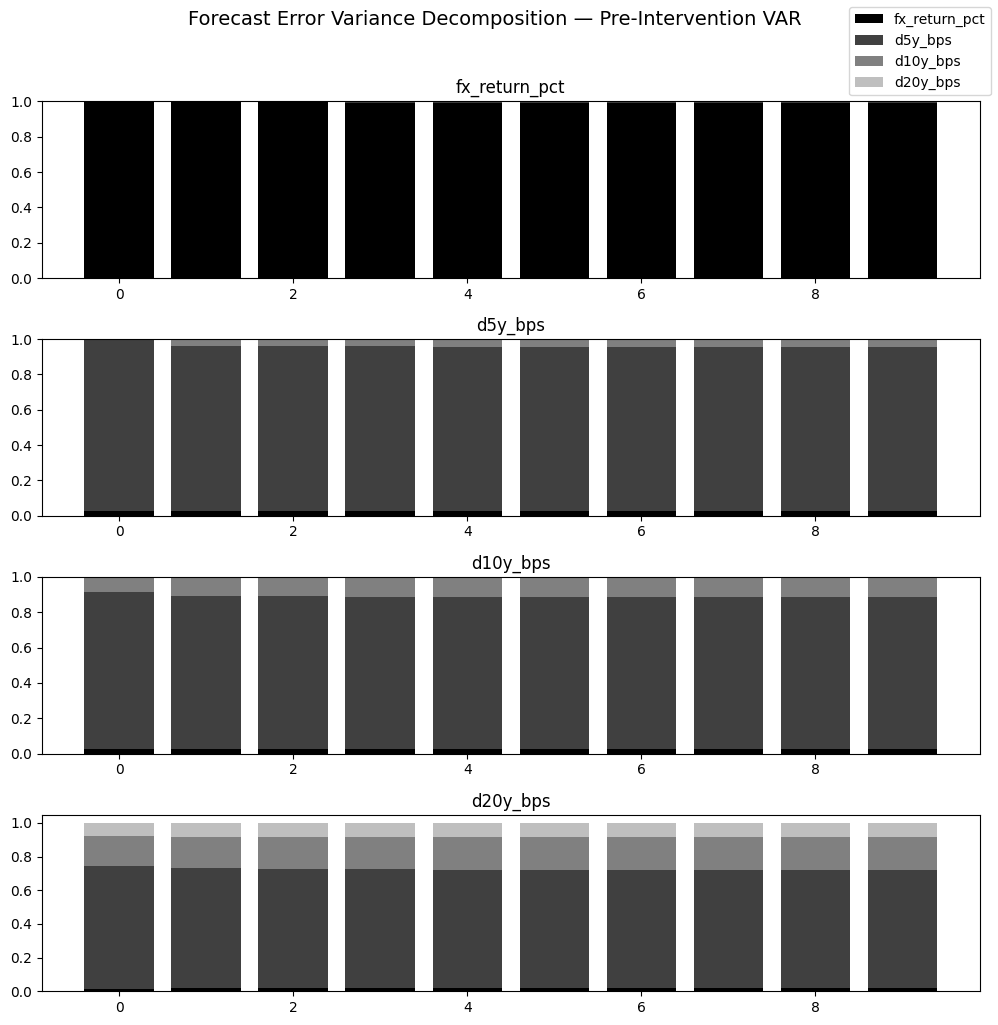

In [10]:
FEVD_HORIZON = 10

fevd = var_fit.fevd(FEVD_HORIZON)
print(fevd.summary())

fig = fevd.plot()
fig.suptitle(
    "Forecast Error Variance Decomposition — Pre-Intervention VAR",
    y=1.02,
    fontsize=14
)
plt.tight_layout()
plt.show()

The VAR provides little evidence of a strong short-run relationship between GBP/USD returns and gilt yield changes. FEVD shows that GBP/USD shocks explain only a small proportion of gilt yield forecast-error variance, while gilt shocks explain very little of GBP/USD forecast-error variance. This is consistent with the Granger-causality tests, which find no statistically significant predictive relationship between GBP/USD returns and 10-year gilt yield changes.

### No-BoE-intervention fixed-origin VAR counterfactual

In [11]:
def level_metrics(actual_percent, forecast_percent):
    actual = np.asarray(actual_percent, dtype=float)
    pred = np.asarray(forecast_percent, dtype=float)
    return {
        "MAE_bps": mean_absolute_error(actual, pred) * 100,
        "RMSE_bps": np.sqrt(mean_squared_error(actual, pred)) * 100,
    }

def reconstruct_levels(last_row, stationary_forecast):
    fc = pd.DataFrame(stationary_forecast, columns=VAR_COLUMNS)

    out = pd.DataFrame()
    out["gbpusd"] = float(last_row["gbpusd"]) * np.exp(
        np.cumsum(fc["fx_return_pct"].to_numpy()) / 100
    )
    out["yield_5y"] = float(last_row["yield_5y"]) + np.cumsum(
        fc["d5y_bps"].to_numpy()
    ) / 100
    out["yield_10y"] = float(last_row["yield_10y"]) + np.cumsum(
        fc["d10y_bps"].to_numpy()
    ) / 100
    out["yield_20y"] = float(last_row["yield_20y"]) + np.cumsum(
        fc["d20y_bps"].to_numpy()
    ) / 100
    return out

In [12]:
HORIZON = len(counterfactual_window)

cf_stationary = var_fit.forecast(
    information_stationary[VAR_COLUMNS].to_numpy()[-BEST_LAG:],
    steps=HORIZON
)

cf_levels = reconstruct_levels(information_set.iloc[-1], cf_stationary)
cf_stationary_df = pd.DataFrame(cf_stationary, columns=VAR_COLUMNS)

var_no_boe = counterfactual_window[
    ["date", "gbpusd", "yield_5y", "yield_10y", "yield_20y"]
].copy().reset_index(drop=True)

for c in ["gbpusd", "yield_5y", "yield_10y", "yield_20y"]:
    var_no_boe[f"VAR_counterfactual_{c}"] = cf_levels[c].to_numpy()

for c in VAR_COLUMNS:
    var_no_boe[f"VAR_counterfactual_{c}"] = cf_stationary_df[c].to_numpy()

var_no_boe["10y_gap_bps"] = (
    var_no_boe["yield_10y"] - var_no_boe["VAR_counterfactual_yield_10y"]
) * 100

var_no_boe

,date,gbpusd,yield_5y,yield_10y,yield_20y,VAR_counterfactual_gbpusd,VAR_counterfactual_yield_5y,VAR_counterfactual_yield_10y,VAR_counterfactual_yield_20y,VAR_counterfactual_fx_return_pct,VAR_counterfactual_d5y_bps,VAR_counterfactual_d10y_bps,VAR_counterfactual_d20y_bps,10y_gap_bps
0,2022-09-28,0.9307,4.2254,4.0517,4.0178,0.934298,4.530251,4.491939,4.967999,0.654809,1.145081,5.783902,9.729857,-44.023902
1,2022-09-29,0.9063,4.3110,4.1210,4.0560,0.938999,4.531916,4.511907,4.979111,0.501953,0.166522,1.996832,1.111261,-39.090734
2,2022-09-30,0.8953,4.3172,4.1021,3.9372,0.939611,4.510955,4.500029,4.955173,0.065060,-2.096135,-1.187838,-2.393817,-39.792896
3,2022-10-03,0.8865,4.1235,3.9766,4.0105,0.939518,4.495401,4.484793,4.935339,-0.009883,-1.555379,-1.523560,-1.983379,-50.819336
4,2022-10-04,0.8769,4.0157,3.9036,4.1185,0.939216,4.491297,4.477428,4.926453,-0.032088,-0.410430,-0.736540,-0.888606,-57.382796
5,2022-10-05,0.8893,4.1345,4.0527,4.3022,0.938921,4.491601,4.474535,4.923442,-0.031462,0.030438,-0.289264,-0.301087,-42.183532
6,2022-10-06,0.8929,4.2720,4.2134,4.4597,0.938913,4.493607,4.474946,4.924130,-0.000811,0.200591,0.041031,0.068738,-26.154563
7,2022-10-07,0.8995,4.3036,4.2826,4.5771,0.939086,4.495700,4.476407,4.925807,0.018409,0.209303,0.146095,0.167732,-19.380658
8,2022-10-10,0.9051,4.5375,4.5445,4.9129,0.939311,4.497363,4.477703,4.927173,0.023960,0.166323,0.129640,0.136557,6.679702
9,2022-10-11,0.9023,4.4362,4.4839,4.9591,0.939526,4.498659,4.478609,4.928040,0.022856,0.129604,0.090555,0.086744,0.529147


The VAR was conditioned on information available through **27 September 2022** and then used to generate a fixed-origin counterfactual from **28 September onward**, without incorporating post-intervention observations.

For the **10-year gilt yield**, the observed yield on 28 September was **4.05%**, compared with a VAR counterfactual of approximately **4.49%**, giving a model-based gap of about **−44 basis points**. The negative gap persisted over the following trading days and reached approximately **−57 basis points on 4 October**, meaning observed yields were substantially below the path predicted from pre-intervention information.

The difference was not permanent. By **10–12 October**, actual yields had risen back to, and briefly above, the VAR counterfactual before falling below it again. Therefore, the results indicate a sizeable **early post-intervention divergence** between observed 10-year yields and the no-intervention VAR baseline, but not a persistent gap throughout the entire period.

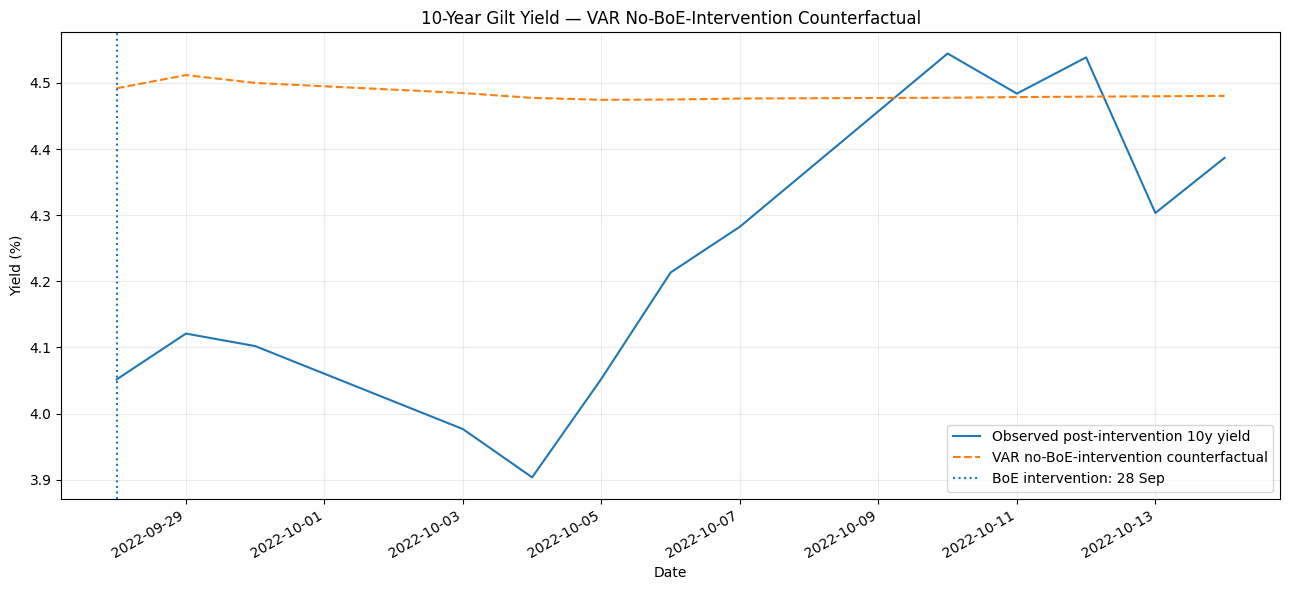

In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(var_no_boe["date"], var_no_boe["yield_10y"], label="Observed post-intervention 10y yield")
ax.plot(
    var_no_boe["date"],
    var_no_boe["VAR_counterfactual_yield_10y"],
    "--",
    label="VAR no-BoE-intervention counterfactual"
)
ax.axvline(INTERVENTION_DATE, linestyle=":", linewidth=1.5, label="BoE intervention: 28 Sep")
ax.set_title("10-Year Gilt Yield — VAR No-BoE-Intervention Counterfactual")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The VAR counterfactual remains close to **4.48–4.51%** over the post-intervention period, while the observed 10-year gilt yield falls sharply immediately after the **28 September BoE intervention**.

The largest divergence occurs in the first few trading days, with observed yields around **40–57 basis points below** the VAR counterfactual. The gap then narrows as yields rise, with the observed series briefly reaching or exceeding the counterfactual around **10–12 October**, before falling below it again.

## 9. Ex-post 10-year forecast gap

In [14]:
gap_table = var_no_boe[
    ["date", "yield_10y", "VAR_counterfactual_yield_10y", "10y_gap_bps"]
].copy()

gap_table

,date,yield_10y,VAR_counterfactual_yield_10y,10y_gap_bps
0,2022-09-28,4.0517,4.491939,-44.023902
1,2022-09-29,4.1210,4.511907,-39.090734
2,2022-09-30,4.1021,4.500029,-39.792896
3,2022-10-03,3.9766,4.484793,-50.819336
4,2022-10-04,3.9036,4.477428,-57.382796
5,2022-10-05,4.0527,4.474535,-42.183532
6,2022-10-06,4.2134,4.474946,-26.154563
7,2022-10-07,4.2826,4.476407,-19.380658
8,2022-10-10,4.5445,4.477703,6.679702
9,2022-10-11,4.4839,4.478609,0.529147


The observed 10-year gilt yield was substantially below the no-BoE-intervention VAR counterfactual immediately after 28 September. The gap was about **−44 bps on 28 September** and reached its largest magnitude of approximately **−57 bps on 4 October**.

The gap then narrowed as observed yields increased, becoming approximately zero or slightly positive between **10–12 October**, before turning negative again on 13–14 October.

In [15]:
OUTPUT_DIR = Path("outputs") / "var_no_boe_intervention"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

var_no_boe.to_csv(
    OUTPUT_DIR / "var_no_boe_intervention_counterfactual.csv",
    index=False
)

cf_exog = var_no_boe[
    ["date", "VAR_counterfactual_fx_return_pct",
     "VAR_counterfactual_d5y_bps", "VAR_counterfactual_d20y_bps"]
].copy()
cf_exog.columns = ["date", "VAR_fx_return_pct", "VAR_d5y_bps", "VAR_d20y_bps"]

cf_exog.to_csv(
    OUTPUT_DIR / "var_no_boe_exog_for_arimax.csv",
    index=False
)

with open(OUTPUT_DIR / "var_specification.json", "w") as f:
    json.dump({"best_lag_aic": int(BEST_LAG), "variables": VAR_COLUMNS}, f, indent=2)

print("Saved to:", OUTPUT_DIR.resolve())

Saved to: /Users/qp252008/Downloads/Dissertation/outputs/var_no_boe_intervention


### Summary

The post-crisis VAR shows that movements across the **5-year, 10-year and 20-year gilt yields are strongly interconnected**, while the relationship between gilt yields and GBP/USD returns is comparatively weak. In particular, 5-year yield changes provide significant predictive information for 10-year yield changes.

The fixed-origin no-BoE-intervention counterfactual keeps the 10-year yield near **4.48–4.51%**. Observed yields initially fell well below this baseline, with the gap reaching about **−57 bps on 4 October**, before narrowing later.

Overall, the results indicate a substantial change in gilt-market behaviour following the BoE intervention, but the difference should be interpreted as a **model-based counterfactual gap rather than a causal estimate of the intervention's effect**.